<a href="https://colab.research.google.com/github/muhendis/langchain-langgraph-llm-uygulamalari/blob/master/part4/03_build_rag_search_agent_with_langgraph.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


In this tutorial we will build a [retrieval](https://docs.langchain.com/oss/python/langchain/retrieval) agent using LangGraph.

LangChain offers built-in [agent](https://docs.langchain.com/oss/python/langchain/agents) implementations, implemented using [LangGraph](https://docs.langchain.com/oss/python/langgraph/overview) primitives. If deeper customization is required, agents can be implemented directly in LangGraph. This guide demonstrates an example implementation of a retrieval agent. [Retrieval](https://docs.langchain.com/oss/python/langchain/retrieval) agents are useful when you want an LLM to make a decision about whether to retrieve context from a vectorstore or respond to the user directly.


You'll learn how to combine Retrieval Augmented Generation (RAG) for accessing internal knowledge, tool usage for interacting with external services like web search, and agentic reasoning to create robust and capable LLM systems.


# Environment Setup

In [1]:
!pip install -U "langchain[google-genai]" langchain_chroma langchain_community
!pip install rich

In [2]:
import os
os.environ["GOOGLE_API_KEY"] = "Your-key"
os.environ["TAVILY_API_KEY"] = "Your-key" #https://app.tavily.com/home


In [3]:
import bs4
import os
from typing import Literal

# --- Libraries ---
from langchain_chroma import Chroma
from langchain_community.document_loaders import WebBaseLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_google_genai import GoogleGenerativeAIEmbeddings, ChatGoogleGenerativeAI
from langchain.chat_models import init_chat_model
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition
from langchain_core.messages import HumanMessage, SystemMessage


# 1. Knowledge Base Construction

Building a RAG system from external documents.

In [4]:

embeddings = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001")

loader = WebBaseLoader(
    web_paths=("https://lilianweng.github.io/posts/2023-06-23-agent/",),
    bs_kwargs=dict(
        parse_only=bs4.SoupStrainer(
            class_=("post-content", "post-title", "post-header")
        )
    ),
)
docs = loader.load()

text_splitter = RecursiveCharacterTextSplitter(chunk_size=1000, chunk_overlap=200)
all_splits = text_splitter.split_documents(docs)

vector_store = Chroma.from_documents(
    documents=all_splits,
    embedding=embeddings,
    collection_name="agent_blog_context"
)

# 2. Tool Definition

Creating and integrating tools for both internal knowledge retrieval and external web searches.

In [5]:
@tool(response_format="content_and_artifact")
def retrieve_context(query: str):
    """
    Searches the internal vector database to retrieve relevant documents.
    """
    # Basit bir simülasyon: Eğer boş sorgu gelirse boş dön
    if not query: return "", []

    retrieved_docs = vector_store.similarity_search(query, k=2)
    serialized = "\n\n".join(
        (f"Source: {doc.metadata}\nContent: {doc.page_content}")
        for doc in retrieved_docs
    )
    return serialized, retrieved_docs

tavily_tool = TavilySearchResults(
    max_results=3,
    description="Performs a live web search."
)

/tmp/ipython-input-107160867.py:16: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(


# 3. GRADER


In [6]:

# Model Init (Gemini-2.0-flash kullanıyoruz)
llm = init_chat_model("google_genai:gemini-2.0-flash", temperature=0)

class GradeDocuments(BaseModel):
    """Binary score for relevance check."""
    binary_score: str = Field(description="'yes' if relevant, 'no' if not relevant")

structured_llm_grader = llm.with_structured_output(GradeDocuments)

# 4. NODES (DÜĞÜMLER)


In [8]:

def generate_query_or_respond(state: MessagesState):
    """
    Step 1: Agent decides. We force it to see ONLY the RAG tool.
    """
    print("---NODE: DECIDE (Agent)---")

    system_prompt = (
        "You are a helpful assistant. "
        "For any fact-based question, you MUST use the 'retrieve_context' tool first. "
        "Only answer directly if it is a simple math problem or greeting."
    )

    messages = [SystemMessage(content=system_prompt)] + state["messages"]

    # Kilit Nokta: Agent burada sadece RAG tool'unu görür. Search tool'unu göremez.
    # Bu sayede search yapma şansı yoktur, mecbur RAG dener veya cevap verir.
    model_with_tools = llm.bind_tools([retrieve_context])
    response = model_with_tools.invoke(messages)

    return {"messages": [response]}


def grade_documents(state: MessagesState) -> Literal["generate_answer", "web_search_fallback"]:
    """
    Step 2: Check if RAG results are good.
    """
    print("---NODE: GRADE DOCUMENTS---")

    messages = state["messages"]
    last_message = messages[-1] # ToolOutput
    question = messages[0].content
    context = last_message.content

    # 1. Kontrol: Context boş mu?
    if not context:
        print("---DECISION: EMPTY CONTEXT -> WEB SEARCH---")
        return "web_search_fallback"

    # 2. Kontrol: Context alakalı mı?
    grade_prompt = f"""User Question: {question}
    Retrieved Docs: {context}
    Are these docs relevant to answer the question? Answer 'yes' or 'no'."""

    scored_result = structured_llm_grader.invoke(grade_prompt)

    if scored_result.binary_score == "yes":
        print("---DECISION: DOCS GOOD -> GENERATE---")
        return "generate_answer"
    else:
        print("---DECISION: DOCS BAD -> WEB SEARCH---")
        return "web_search_fallback"


def web_search_fallback(state: MessagesState):
    """
    Step 3 (Fallback): Run Tavily manually.
    """
    print("---NODE: WEB SEARCH FALLBACK---")
    messages = state["messages"]
    question = messages[0].content

    # Agent'a sormadan direkt çalıştırıyoruz (Hard Fallback)
    search_results = tavily_tool.invoke(question)

    # Sonucu sisteme enjekte ediyoruz
    return {"messages": [HumanMessage(content=f"Web Search Results: {search_results}")]}


def generate_answer(state: MessagesState):
    """
    Step 4: Final Answer Generation.
    """
    print("---NODE: GENERATE ANSWER---")
    messages = state["messages"]
    question = messages[0].content
    # Son mesaj ya RAG'dan ya da Search'ten gelen context'tir
    context = messages[-1].content

    prompt = f"""Answer the question using the context below.
    Question: {question}
    Context: {context}
    Answer:"""

    response = llm.invoke(prompt)
    return {"messages": [response]}





# 5. GRAPH CONSTRUCTION


In [9]:

workflow = StateGraph(MessagesState)

# Düğümleri Ekle
workflow.add_node("generate_query_or_respond", generate_query_or_respond)
workflow.add_node("retrieve", ToolNode([retrieve_context]))
workflow.add_node("web_search_fallback", web_search_fallback)
workflow.add_node("generate_answer", generate_answer)

# Kenarları Bağla
workflow.add_edge(START, "generate_query_or_respond")

# Conditional Edge: Agent Kararı
# Agent tool çağırırsa -> 'retrieve'
# Çağırmazsa (örn: 3+5) -> END
workflow.add_conditional_edges(
    "generate_query_or_respond",
    tools_condition,
    {
        "tools": "retrieve",
        END: END
    }
)

# Conditional Edge: Grader Kararı
# Retrieve düğümünden sonra mecburi Grader kontrolü
workflow.add_conditional_edges(
    "retrieve",
    grade_documents,
    {
        "generate_answer": "generate_answer",       # İyi -> Cevapla
        "web_search_fallback": "web_search_fallback" # Kötü -> Search
    }
)

# Fallback Edge
workflow.add_edge("web_search_fallback", "generate_answer")
workflow.add_edge("generate_answer", END)

app = workflow.compile()

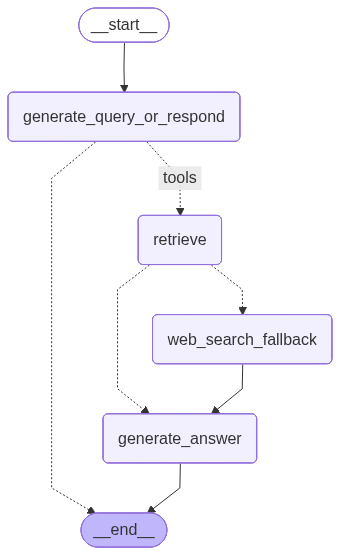

In [10]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

# 6. TESTS


In [11]:


def run_test(case_name, user_input):
    print(f"\n{'='*20} {case_name} {'='*20}")
    inputs = {"messages": [{"role": "user", "content": user_input}]}

    final_text = "No response generated."

    for chunk in app.stream(inputs):
        for node_name, values in chunk.items():
            # Akışın her adımındaki mesajı yakala
            if "messages" in values:
                last_msg = values["messages"][-1]
                # Sadece AI mesajlarını cevap olarak kabul et (Tool mesajlarını değil)
                if hasattr(last_msg, "content") and values["messages"][0].type == "ai":
                    final_text = last_msg.content
                # Eğer akış direkt END'e giderse (3+5 case), ilk node'un çıktısı cevaptır
                elif node_name == "generate_query_or_respond" and not hasattr(last_msg, "tool_calls"):
                    final_text = last_msg.content

    print(f"\nFINAL OUTPUT > {final_text}")

# --- TESTLER ---

# Case 1: Basit Matematik (RAG'a girmemeli, direkt cevaplamalı)
run_test("CASE 1: Math (Direct)", "What is 3+5?")

# Case 2: RAG (İçeride var, 'retrieve' -> 'generate' gitmeli)
run_test("CASE 2: RAG (Internal)", "What is 'Memory' in the context of LLM Agents?")

# Case 3: Search (İçeride yok, 'retrieve' -> 'fallback' -> 'generate' gitmeli)
run_test("CASE 3: Search (External)", "Who won the Euro 2024 final match?")


==================== CASE 1: Math (Direct) ====================
---NODE: DECIDE (Agent)---

FINAL OUTPUT > 3 + 5 = 8

==================== CASE 2: RAG (Internal) ====================
---NODE: DECIDE (Agent)---
---NODE: GRADE DOCUMENTS---
---DECISION: DOCS GOOD -> GENERATE---
---NODE: GENERATE ANSWER---

FINAL OUTPUT > In the context of LLM Agents, 'Memory' refers to the agent's ability to retain and recall information. It can be categorized into:

*   **Short-term memory:** This is akin to in-context learning, where the model utilizes information provided in the prompt to learn.
*   **Long-term memory:** This allows the agent to retain and recall information over extended periods, often using an external database (like a vector store) for storage and fast retrieval. A memory stream, which is a long-term memory module (external database), records a comprehensive list of agents’ experience in natural language.

==================== CASE 3: Search (External) ====================
---NODE:

In [12]:
for chunk in app.stream(
    {
        "messages": [
            {
                "role": "user",
                "content": " Besiktas ?",
            }
        ]
    }
):
    for node, update in chunk.items():
        print("Update from node", node)
        update["messages"][-1].pretty_print()
        print("\n\n")

---NODE: DECIDE (Agent)---
Update from node generate_query_or_respond
================================== Ai Message ==================================
Tool Calls:
  retrieve_context (ed855635-362d-4c1d-9ea5-6a50a415dc39)
 Call ID: ed855635-362d-4c1d-9ea5-6a50a415dc39
  Args:
    query: Besiktas



---NODE: GRADE DOCUMENTS---
---DECISION: DOCS BAD -> WEB SEARCH---
Update from node retrieve
================================= Tool Message =================================
Name: retrieve_context

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: Conversatin samples:
[
  {
    "role": "system",

Source: {'source': 'https://lilianweng.github.io/posts/2023-06-23-agent/'}
Content: You always add a comment briefly describing the purpose of the function definition.
You try to add comments explaining very complex bits of logic.
You always follow the best practices for the requested languages in terms of describing the code written as a defined
package/project.
Pyt